In [3]:
import os

archive_path = project_path + '/data/raw/archive'

print("Files directly inside archive:")
print(os.listdir(archive_path))

Files directly inside archive:
['labeled_anomalies.csv', 'data']


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_path = '/content/drive/MyDrive/Spacecraft-Anomaly-Detection'

data_path = project_path + '/data/raw/archive/data/data'
train_path = data_path + '/train'
test_path = data_path + '/test'

labels_path = project_path + '/data/raw/archive/labeled_anomalies.csv'

labels_df = pd.read_csv(labels_path)

print("SERIAL 08 loaded successfully.")
print("Total channels:", len(labels_df))

SERIAL 08 loaded successfully.
Total channels: 82


In [5]:
# Load A-8 telemetry and its anomaly information

channel = "A-8"

data_A8 = np.load(test_path + "/" + channel + ".npy")

telemetry_A8 = data_A8[:, 0]

A8_info = labels_df[labels_df["chan_id"] == channel].iloc[0]

print("Channel:", channel)
print("Spacecraft:", A8_info["spacecraft"])
print("Telemetry points:", len(telemetry_A8))
print("Anomaly sequences:", A8_info["anomaly_sequences"])
print("Anomaly class:", A8_info["class"])

Channel: A-8
Spacecraft: SMAP
Telemetry points: 8375
Anomaly sequences: [[4569, 8374]]
Anomaly class: [contextual]


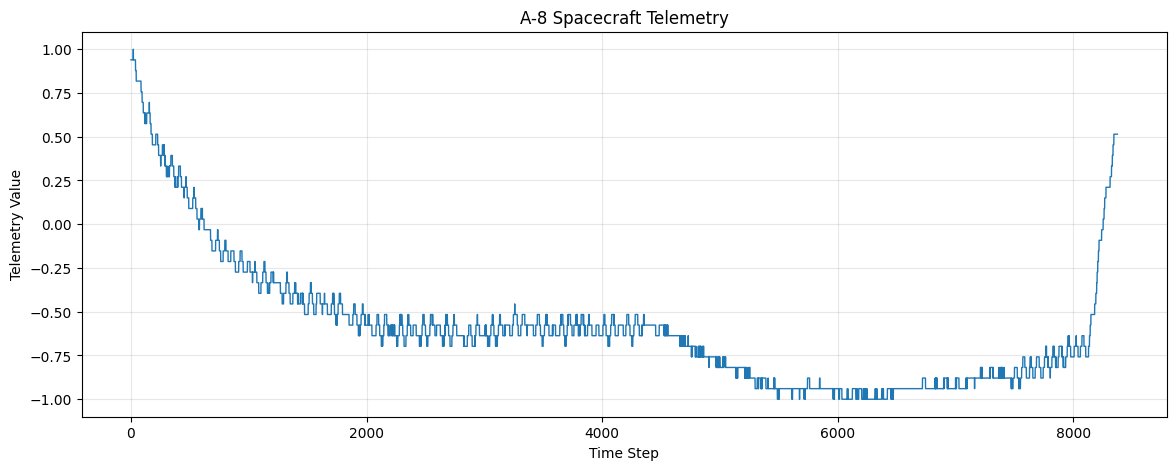

In [6]:
# Plot A-8 telemetry

plt.figure(figsize=(14, 5))

plt.plot(telemetry_A8, linewidth=1)

plt.title("A-8 Spacecraft Telemetry")
plt.xlabel("Time Step")
plt.ylabel("Telemetry Value")
plt.grid(True, alpha=0.3)

plt.show()

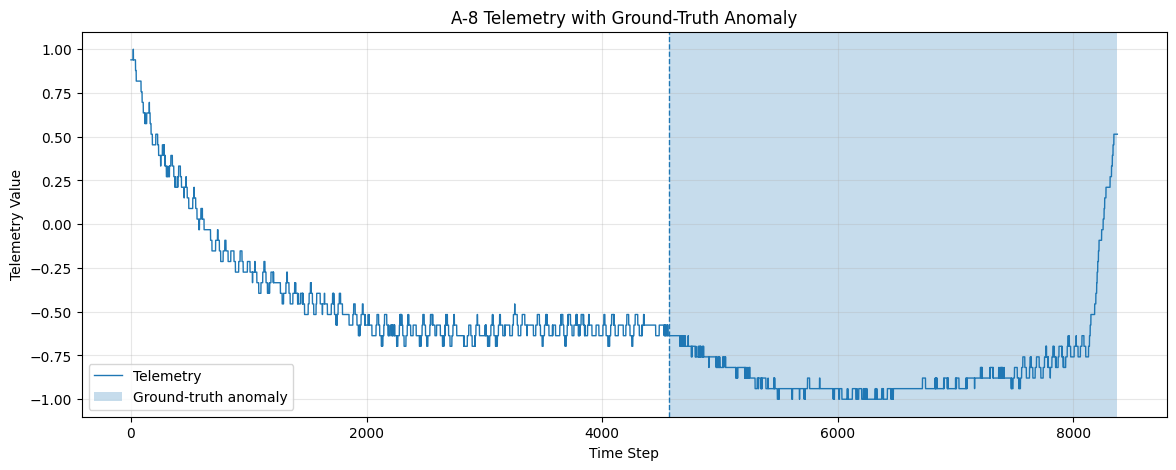

In [7]:
# Plot A-8 telemetry with the ground-truth anomaly region

anomaly_start = 4569
anomaly_end = 8374

plt.figure(figsize=(14, 5))

plt.plot(
    telemetry_A8,
    linewidth=1,
    label="Telemetry"
)

plt.axvspan(
    anomaly_start,
    anomaly_end,
    alpha=0.25,
    label="Ground-truth anomaly"
)

plt.axvline(
    anomaly_start,
    linestyle="--",
    linewidth=1
)

plt.title("A-8 Telemetry with Ground-Truth Anomaly")
plt.xlabel("Time Step")
plt.ylabel("Telemetry Value")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

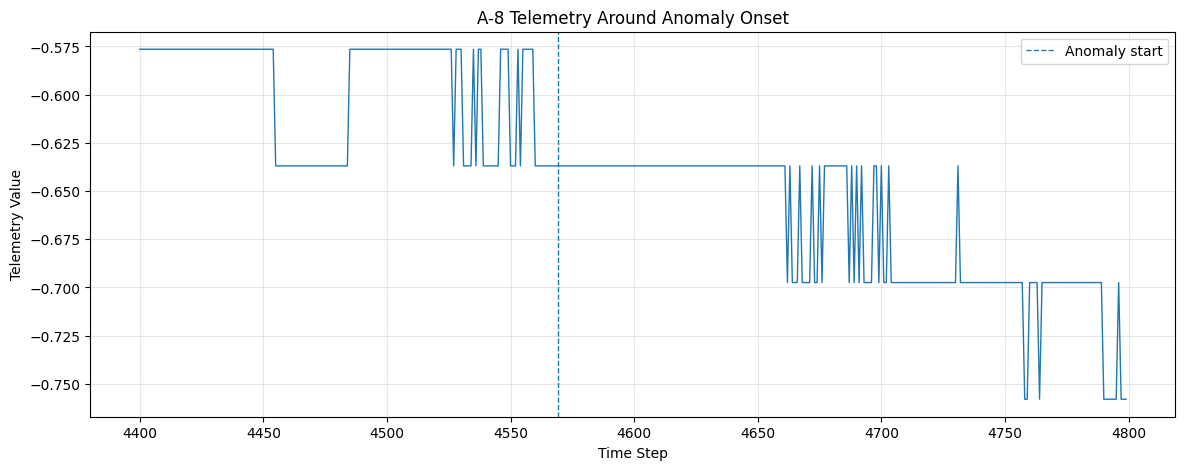

In [8]:
# Zoom in around the A-8 anomaly boundary

start = 4400
end = 4800

plt.figure(figsize=(14, 5))

plt.plot(
    np.arange(start, end),
    telemetry_A8[start:end],
    linewidth=1
)

plt.axvline(
    anomaly_start,
    linestyle="--",
    linewidth=1,
    label="Anomaly start"
)

plt.title("A-8 Telemetry Around Anomaly Onset")
plt.xlabel("Time Step")
plt.ylabel("Telemetry Value")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

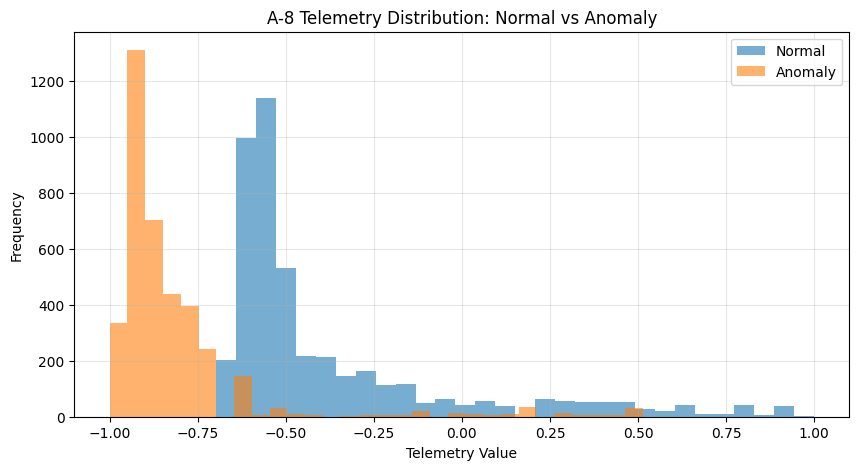

In [9]:
# Compare telemetry distributions: normal vs anomaly

normal_data = telemetry_A8[:anomaly_start]
anomaly_data = telemetry_A8[anomaly_start:anomaly_end + 1]

plt.figure(figsize=(10, 5))

plt.hist(
    normal_data,
    bins=30,
    alpha=0.6,
    label="Normal"
)

plt.hist(
    anomaly_data,
    bins=30,
    alpha=0.6,
    label="Anomaly"
)

plt.title("A-8 Telemetry Distribution: Normal vs Anomaly")
plt.xlabel("Telemetry Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [10]:
# Compare basic statistics

normal_mean = np.mean(normal_data)
normal_std = np.std(normal_data)

anomaly_mean = np.mean(anomaly_data)
anomaly_std = np.std(anomaly_data)

print("Normal period:")
print("Mean:", normal_mean)
print("Standard deviation:", normal_std)

print("\nAnomaly period:")
print("Mean:", anomaly_mean)
print("Standard deviation:", anomaly_std)

Normal period:
Mean: -0.3906871582666503
Standard deviation: 0.35705219656967024

Anomaly period:
Mean: -0.8162289176600386
Standard deviation: 0.24546347972239665


/tmp/ipykernel_4694/93347112.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


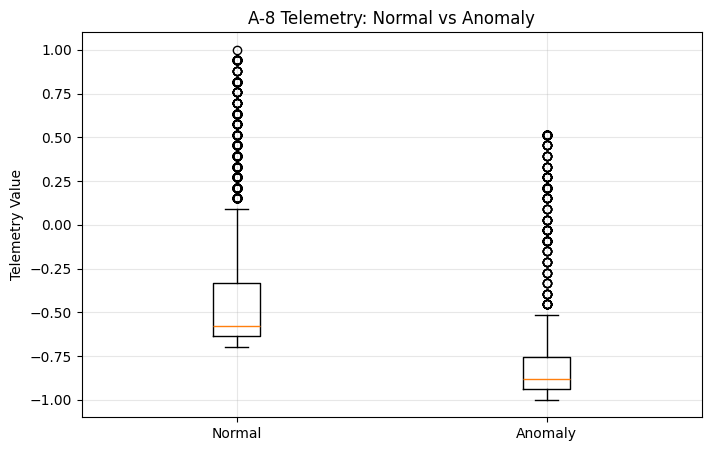

In [11]:
# Compare normal and anomaly distributions with boxplots

plt.figure(figsize=(8, 5))

plt.boxplot(
    [normal_data, anomaly_data],
    labels=["Normal", "Anomaly"]
)

plt.title("A-8 Telemetry: Normal vs Anomaly")
plt.ylabel("Telemetry Value")
plt.grid(True, alpha=0.3)

plt.show()

In [12]:
# Calculate quartiles for normal and anomaly periods

normal_q1 = np.percentile(normal_data, 25)
normal_median = np.percentile(normal_data, 50)
normal_q3 = np.percentile(normal_data, 75)

anomaly_q1 = np.percentile(anomaly_data, 25)
anomaly_median = np.percentile(anomaly_data, 50)
anomaly_q3 = np.percentile(anomaly_data, 75)

print("Normal period:")
print("Q1:", normal_q1)
print("Median:", normal_median)
print("Q3:", normal_q3)

print("\nAnomaly period:")
print("Q1:", anomaly_q1)
print("Median:", anomaly_median)
print("Q3:", anomaly_q3)

Normal period:
Q1: -0.6369642399002466
Median: -0.5764323278789469
Q3: -0.3342305312090079

Anomaly period:
Q1: -0.9395125771295589
Median: -0.8790177394006531
Q3: -0.7580058193673984


In [13]:
# Calculate the interquartile range (IQR)

normal_iqr = normal_q3 - normal_q1
anomaly_iqr = anomaly_q3 - anomaly_q1

print("Normal IQR:", normal_iqr)
print("Anomaly IQR:", anomaly_iqr)

Normal IQR: 0.3027337086912387
Anomaly IQR: 0.18150675776216052


#gitpush

In [14]:
%cd /content/drive/MyDrive/Spacecraft-Anomaly-Detection

!git status

/content/drive/MyDrive/Spacecraft-Anomaly-Detection
Refresh index: 100% (9/9), done.
On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/07_understand_dataset.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	notebooks/08_data_visualization.ipynb

no changes added to commit (use "git add" and/or "git commit -a")


In [15]:
!git add notebooks/08_data_visualization.ipynb
!git commit -m "Complete SERIAL 08 data visualization"
!git push origin main

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@a39582281012.(none)')
Everything up-to-date
